# 🎯 Taller Final Modelos de Analitica




## 📝 Estructura del Notebook

Este notebook sigue 10 pasos fundamentales:
1. **Documentación**
    - Completar información del estudiante y fecha
    - Definir variable objetivo: `Class` (0 = transacción legítima, 1 = fraude)
    - Describir el problema de detección de fraude en tarjetas de crédito
    - Establecer métricas de éxito considerando el desbalance de clases

2. **Importación de librerías y módulos**
    - `pandas` y `numpy` para manipulación de datos
    - `matplotlib` y `seaborn` para visualizaciones
    - `sklearn.model_selection` para `train_test_split`
    - `sklearn.preprocessing` para `StandardScaler`
    - `sklearn.metrics` para métricas de evaluación
    - Modelos: `LogisticRegression`, `RandomForestClassifier`, `GradientBoostingClassifier`

3. **Carga de datos**
    - Verificar la descarga exitosa del dataset (en este caso descargado de kaggle directamente)

4. **Análisis exploratorio (EDA)**
    - Usar `df.describe(include='all')` para estadísticas descriptivas
    - Inspeccionar las primeras filas con `df.head()`
    - Verificar dimensiones con `df.shape`
    - Analizar distribución de la variable objetivo con `df['Class'].value_counts()`
    - Calcular porcentaje de fraude vs no fraude
    - Visualizar distribución temporal con `df['Time'].hist()`
    - Crear histogramas de `Amount` separados por clase
    - Analizar distribución de variables V1-V28 (ya transformadas con PCA)
    - **Recomendación**: Identificar el desbalance de clases (~0.17% fraudes)

5. **Pre-procesamiento**
    - Verificar valores nulos con `df.isnull().sum()`
    - Escalar columnas `Time` y `Amount` usando `StandardScaler`
    - **Hint**: Las variables V1-V28 ya están escaladas
    - Considerar técnicas de balanceo (opcional): SMOTE, undersampling, o ajustar `class_weight='balanced'`
    - Crear nuevas características si es necesario (ej: hora del día desde `Time`)
    - **Recomendación**: Guardar el scaler para aplicarlo consistentemente

6. **Análisis de correlación**
    - Calcular matriz de correlación con `df.corr()`
    - Visualizar con `sns.heatmap()` usando `cmap='coolwarm'`
    - Identificar variables más correlacionadas con `Class`
    - Analizar multicolinealidad entre features
    - **Hint**: Buscar correlaciones > 0.1 o < -0.1 con la variable objetivo

7. **División de datos en entrenamiento y prueba**
    - Separar features (X) y target (y)
    - Usar `train_test_split` con `test_size=0.2` y `random_state=42`
    - Implementar `stratify=y` para mantener proporción de clases
    - Verificar distribución en ambos conjuntos
    - **Recomendación**: Imprimir shape de X_train, X_test, y_train, y_test

8. **Modelado y evaluación de desempeño**
    
    **Modelo 1: Regresión Logística**
    - Entrenar con `class_weight='balanced'` por el desbalance
    - Predecir en conjunto de prueba
    - Calcular matriz de confusión con `confusion_matrix`
    - Calcular métricas: precision, recall, F1-score, AUC-ROC
    - **Hint**: Usar `classification_report` para reporte completo
    
    **Modelo 2: Random Forest**
    - Configurar `n_estimators=100`, `max_depth=10`, `class_weight='balanced'`
    - Obtener importancia de características con `feature_importances_`
    - Calcular probabilidades para curva ROC
    - **Recomendación**: Visualizar top 10 features más importantes
    
    **Modelo 3: Gradient Boosting**
    - Configurar `n_estimators=100`, `learning_rate=0.1`, `max_depth=5`
    - Evaluar con las mismas métricas
    - **Hint**: Este modelo suele ser más lento pero muy efectivo
    
    **Para cada modelo calcular**:
    - Accuracy (no es la mejor métrica aquí)
    - Precision (minimizar falsos positivos)
    - Recall (capturar la mayor cantidad de fraudes)
    - F1-Score (balance entre precision y recall)
    - AUC-ROC (capacidad de discriminación)
    - Curva ROC con `roc_curve` y `roc_auc_score`

9. **Comparación de modelos**
    - Crear DataFrame con métricas de los 3 modelos
    - Incluir columnas: Modelo, Accuracy, Precision, Recall, F1-Score, AUC-ROC
    - Ordenar por Recall y F1-Score (más importantes en fraude)
    - Visualizar comparación con gráfico de barras
    - Analizar matriz de confusión de cada modelo
    - **Recomendación**: Priorizar Recall para minimizar fraudes no detectados
    - **Hint**: Considerar el trade-off entre falsos positivos y falsos negativos

10. **Exportación de resultados**
     - Crear tabla resumen con `pd.DataFrame`
     - Exportar con `df_results.to_csv('model_benchmarking.csv', index=False)`
     - Guardar mejores parámetros del modelo ganador
     - Documentar conclusiones y recomendaciones
     - **Opcional**: Guardar modelo con `pickle` o `joblib` para producción
     - **Recomendación**: Incluir timestamp en nombre del archivo


---

## 📋 1. Documentación

-Diligenciar la Información relacionada al Taller-

* **Estudiante:** *[Anguihero]*  
* **Fecha:** [2099/12/31]  
* **Variable Objetivo:** [`Class` (0 = transacción legítima, 1 = fraude)]
* **Descripción del problema:** [Credit Card Fraud Detection : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data]


**Detección de Fraude en Tarjetas de Crédito**

Contexto:
Es fundamental que las compañías de tarjetas de crédito puedan identificar transacciones fraudulentas
para proteger a sus clientes y evitar que sean cobrados por compras que no realizaron.

Conjunto de Datos:
- Transacciones de tarjetas de crédito realizadas en septiembre de 2013 por tarjetahabientes europeos
- Periodo: 2 días
- Total de transacciones: 284,807
- Transacciones fraudulentas: 492 (0.172% del total)
- Problema: Dataset altamente desbalanceado

Variables:
- V1, V2, ..., V28: 28 componentes principales obtenidos mediante PCA (variables transformadas por confidencialidad)
- Time: Segundos transcurridos entre cada transacción y la primera transacción del dataset
- Amount: Monto de la transacción
- Class: Variable objetivo (0 = transacción legítima, 1 = fraude)

Desafíos:
1. Desbalance extremo de clases (99.828% legítimas vs 0.172% fraudulentas)
2. No disponibilidad de features originales (solo componentes PCA)
3. Necesidad de maximizar detección de fraudes minimizando falsos positivos

Métricas de Éxito:
- Recall: Capturar la mayor cantidad posible de fraudes (minimizar falsos negativos)
- Precision: Reducir falsos positivos para evitar bloqueos innecesarios
- F1-Score: Balance entre Precision y Recall
- AUC-ROC: Capacidad general de discriminación del modelo
- AUPRC (Area Under Precision-Recall Curve): Recomendada para datasets desbalanceados
Nota: Accuracy NO es una métrica adecuada debido al desbalance de clases

---

## 📋 2. Importación de librerías y modulos

    - `pandas` y `numpy` para manipulación de datos
    - `matplotlib` y `seaborn` para visualizaciones
    - `sklearn.model_selection` para `train_test_split`
    - `sklearn.preprocessing` para `StandardScaler`
    - `sklearn.metrics` para métricas de evaluación
    - Modelos: `LogisticRegression`, `RandomForestClassifier`, `GradientBoostingClassifier`

In [ ]:
import kagglehub
# importar los demas modulos necesarios ejemplo pandas, numpy, matplotlib, seaborn, sklearn, etc.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, kNeighborsClassifier


---

## 📋 3. Carga de datos

- Verificar la descarga exitosa del dataset (en este caso descargado de kaggle directamente)

In [6]:
# cargar datos desde Kaggle https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data    

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(path +  "/creditcard.csv")


---

## 📋 4. Análisis exploratorio (EDA)
    - Usar `df.describe(include='all')` para estadísticas descriptivas
    - Inspeccionar las primeras filas con `df.head()`
    - Verificar dimensiones con `df.shape`
    - Analizar distribución de la variable objetivo con `df['Class'].value_counts()`
    - Calcular porcentaje de fraude vs no fraude
    - Visualizar distribución temporal con `df['Time'].hist()`
    - Crear histogramas de `Amount` separados por clase
    - Analizar distribución de variables V1-V28 (ya transformadas con PCA)
    - **Recomendación**: Identificar el desbalance de clases (~0.17% fraudes)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# realizar análisis exploratorio (EDA) usando descriptivos estadísticos .describe(include='all') y visualizaciones gráficas como histogramas, diagramas de caja, mapas de calor, etc.
df.describe(include='all')

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [14]:
# Analizar distribución de la variable objetivo
# Calcular porcentaje de fraude vs no fraude
print(df['Class'].value_counts())
df['Class'].value_counts(normalize=True) * 100

Class
0    284315
1       492
Name: count, dtype: int64


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

<Axes: >

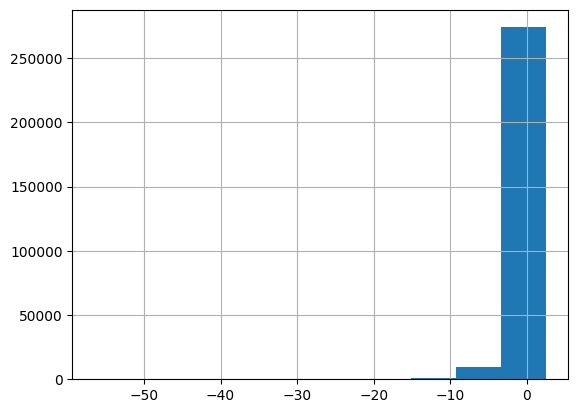

In [31]:
df['V1'].hist()

<Axes: >

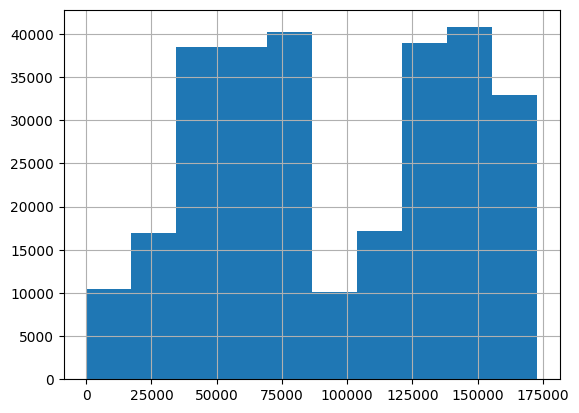

In [15]:
df['Time'].hist()

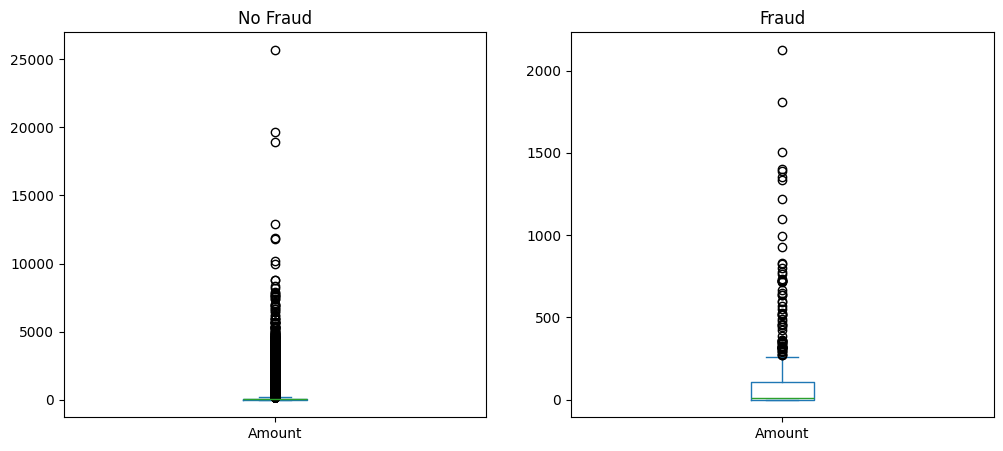

In [17]:
# Crear boxplot de `Amount` separados por clase
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
df[df['Class'] == 0]['Amount'].plot.box()
plt.title('No Fraud')
plt.subplot(1,2,2)
df[df['Class'] == 1]['Amount'].plot.box()
plt.title('Fraud')
plt.show()

---

## 📋 5. Pre-procesamiento

In [ ]:
# realizar pre-procesamiento de datos como detección y manejo de valores nulos, codificación de variables categóricas, escalado de características, etc.


In [18]:
# Verificar valores nulos 
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [19]:
# Escalar columnas `Time` y `Amount` usando `StandardScaler`
scaler = StandardScaler()
df[['Time', 'Amount']] = scaler.fit_transform(df[['Time', 'Amount']])

---

## 📋 6. Análisis de correlación

In [ ]:
# realizar análisis de correlación entre variables utilizando matrices de correlación y visualizaciones como mapas de calor.

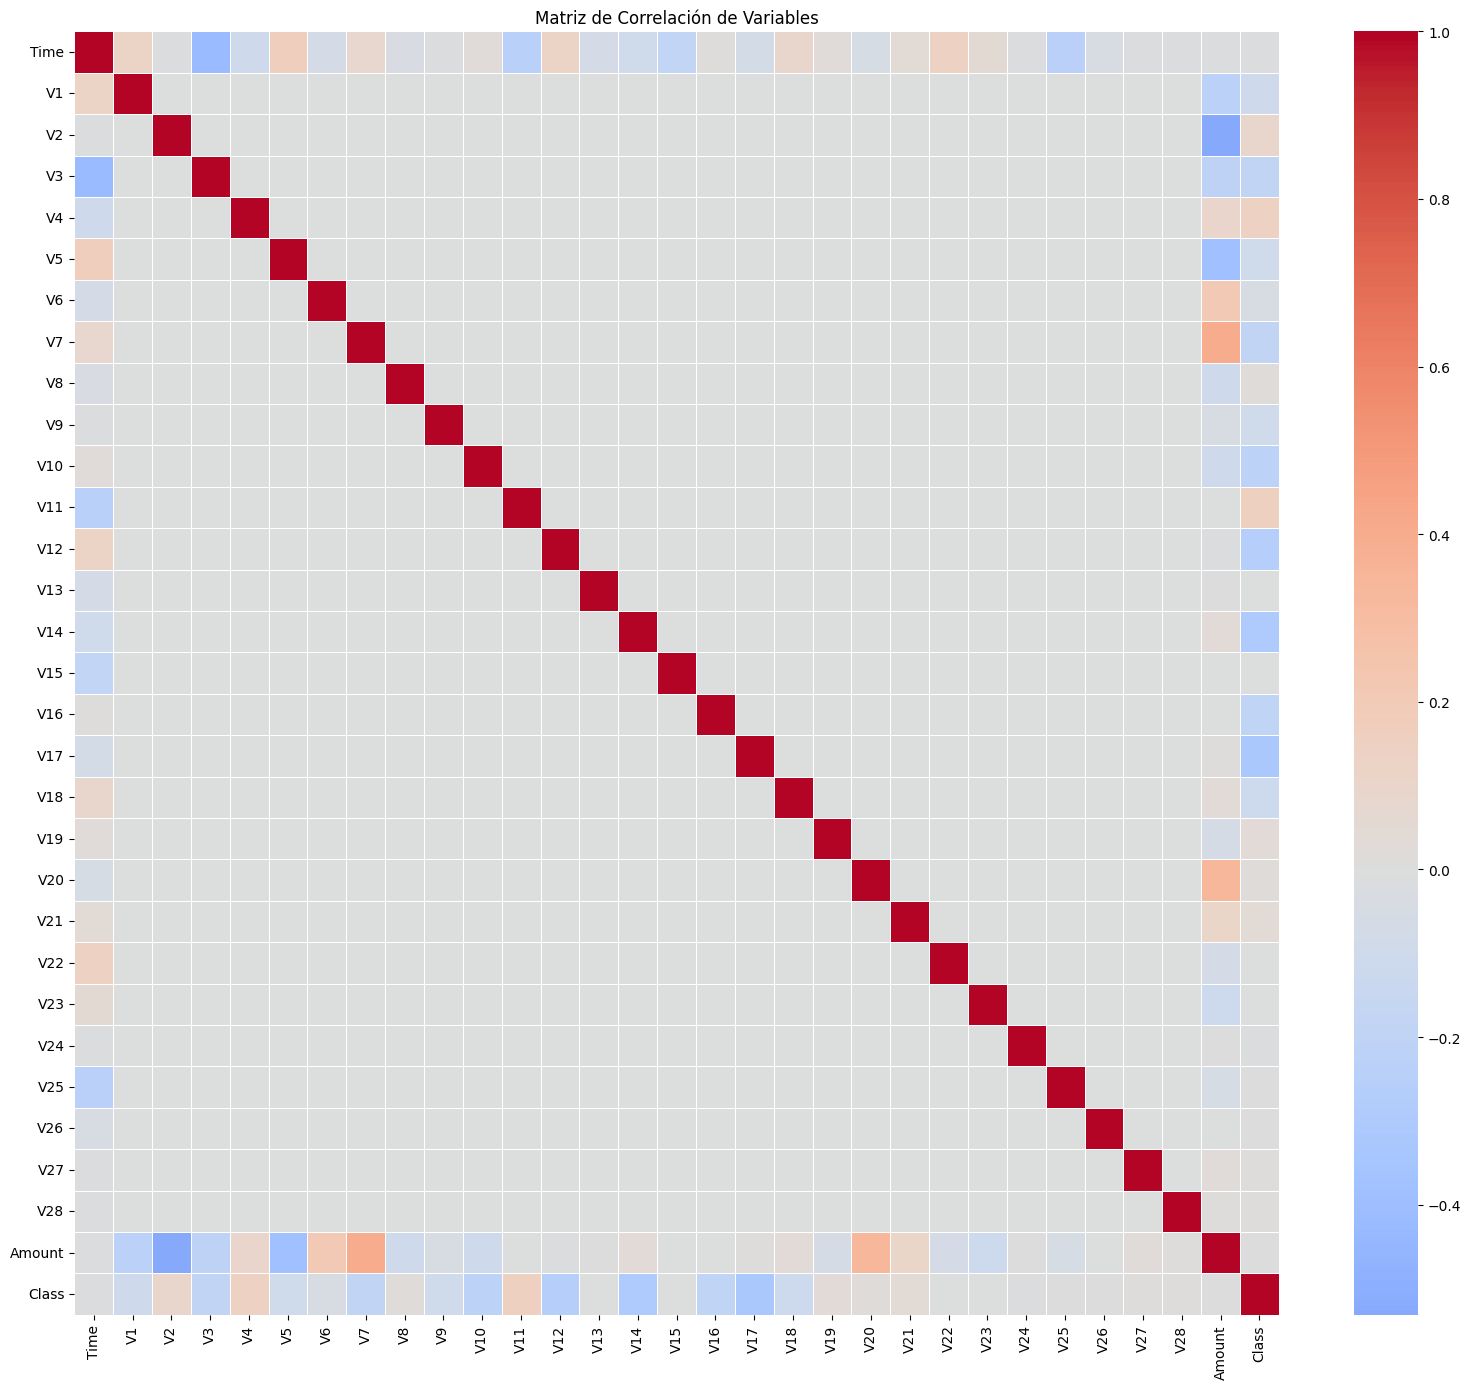


Correlación con la variable objetivo 'Class':
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


Variables con correlación significativa (|r| > 0.1):
Class    1.000000
V11      0.154876
V4       0.133447
V1      -0.101347
V18     -0.111485
V7      -0.187257
V3      -0.192961
V16     -0.196539
V10     -0.216883
V12     -0.260593
V14     -0.302544
V17     -0.326481
Name: Class, dtype: float64


In [22]:
#   - Calcular matriz de correlación con `df.corr()`
#     - Visualizar con `sns.heatmap()` usando `cmap='coolwarm'`
#     - Identificar variables más correlacionadas con `Class`
# Calcular matriz de correlación
corr_matrix = df.corr()

# Visualizar con heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables')
plt.tight_layout()
plt.show()

# Identificar variables más correlacionadas con Class
class_corr = corr_matrix['Class'].sort_values(ascending=False)
print("\nCorrelación con la variable objetivo 'Class':")
print(class_corr)

# Mostrar variables con correlación > 0.1 o < -0.1
print("\n\nVariables con correlación significativa (|r| > 0.1):")
significant_corr = class_corr[(class_corr > 0.1) | (class_corr < -0.1)]
print(significant_corr)

---

## 📋 7. División de datos en entrenamiento y prueba

In [ ]:

# dividir los datos en conjuntos de entrenamiento y prueba utilizando una proporción adecuada (por ejemplo, 80% entrenamiento y 20% prueba).


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

---

## 📋 8. Modelado y evaluación de desempeño

In [ ]:
# ajustar varios modelos de clasificación supervisada (por ejemplo, regresión logística, árboles de decisión, bosques aleatorios, máquinas de vectores de soporte, etc.) utilizando el conjunto de entrenamiento.

In [ ]:
# regresion logistica con class_weight='balanced'

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

# Predicciones
y_test_pred_logreg = log_reg.predict(X_test)
y_test_proba_logreg = log_reg.predict_proba(X_test)[:, 1]

# Matriz de confusión
cm_logreg = confusion_matrix(y_test, y_test_pred_logreg)
tn, fp, fn, tp = cm_logreg.ravel()

# Calcular métricas individuales
acc_logreg = accuracy_score(y_test, y_test_pred_logreg)
precision_logreg = precision_score(y_test, y_test_pred_logreg)
recall_logreg = recall_score(y_test, y_test_pred_logreg)
f1_logreg = f1_score(y_test, y_test_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_test_proba_logreg)

# Crear DataFrame con métricas
metrics_df = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'TP': [tp],
    'FP': [fp],
    'TN': [tn],
    'FN': [fn],
    'Accuracy': [acc_logreg],
    'Precision': [precision_logreg],
    'Recall': [recall_logreg],
    'F1-Score': [f1_logreg],
    'AUC-ROC': [auc_logreg]
})

# Mostrar resultados
print("="*60)
print("LOGISTIC REGRESSION - RESULTS")
print("="*60)
print("\nConfusion Matrix:")
print(cm_logreg)
print(f"\nTP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print("\n" + "="*60)
print("Classification Report:")
print(classification_report(y_test, y_test_pred_logreg))
print("="*60)
print("\nMetrics Summary:")
print(metrics_df.to_string(index=False))
print("="*60)

LOGISTIC REGRESSION - RESULTS

Confusion Matrix:
[[55475  1389]
 [    8    90]]

TP: 90, FP: 1389, TN: 55475, FN: 8

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


Metrics Summary:
              Model  TP   FP    TN  FN  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression  90 1389 55475   8  0.975475   0.060852 0.918367  0.114141 0.972167


In [29]:


# regresion logistica con class_weight='balanced'

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

# Predicciones
y_test_pred_logreg = log_reg.predict(X_test)
y_test_proba_logreg = log_reg.predict_proba(X_test)[:, 1]

# Matriz de confusión
cm_logreg = confusion_matrix(y_test, y_test_pred_logreg)
tn, fp, fn, tp = cm_logreg.ravel()

# Calcular métricas individuales
acc_logreg = accuracy_score(y_test, y_test_pred_logreg)
precision_logreg = precision_score(y_test, y_test_pred_logreg)
recall_logreg = recall_score(y_test, y_test_pred_logreg)
f1_logreg = f1_score(y_test, y_test_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_test_proba_logreg)

# Crear DataFrame con métricas
metrics_df_logreg = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'TP': [tp],
    'FP': [fp],
    'TN': [tn],
    'FN': [fn],
    'Accuracy': [acc_logreg],
    'Precision': [precision_logreg],
    'Recall': [recall_logreg],
    'F1-Score': [f1_logreg],
    'AUC-ROC': [auc_logreg]
})

# Mostrar resultados
print("="*60)
print("LOGISTIC REGRESSION - RESULTS")
print("="*60)
print("\nConfusion Matrix:")
print(cm_logreg)
print(f"\nTP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print("\n" + "="*60)
print("Classification Report:")
print(classification_report(y_test, y_test_pred_logreg))
print("="*60)
print("\nMetrics Summary:")
print(metrics_df_logreg.to_string(index=False))
print("="*60)

LOGISTIC REGRESSION - RESULTS

Confusion Matrix:
[[55475  1389]
 [    8    90]]

TP: 90, FP: 1389, TN: 55475, FN: 8

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


Metrics Summary:
              Model  TP   FP    TN  FN  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression  90 1389 55475   8  0.975475   0.060852 0.918367  0.114141 0.972167


In [30]:


#random forest con class_weight='balanced'

rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_clf.fit(X_train, y_train)

# Predicciones
y_test_pred_rf = rf_clf.predict(X_test)
y_test_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()

# Calcular métricas individuales
acc_rf = accuracy_score(y_test, y_test_pred_rf)
precision_rf = precision_score(y_test, y_test_pred_rf)
recall_rf = recall_score(y_test, y_test_pred_rf)
f1_rf = f1_score(y_test, y_test_pred_rf)
auc_rf = roc_auc_score(y_test, y_test_proba_rf)

# Crear DataFrame con métricas
metrics_df_rf = pd.DataFrame({
    'Model': ['Random Forest'],
    'TP': [tp],
    'FP': [fp],
    'TN': [tn],
    'FN': [fn],
    'Accuracy': [acc_rf],
    'Precision': [precision_rf],
    'Recall': [recall_rf],
    'F1-Score': [f1_rf],
    'AUC-ROC': [auc_rf]
})

# Mostrar resultados
print("="*60)
print("RANDOM FOREST - RESULTS")
print("="*60)
print("\nConfusion Matrix:")
print(cm_rf)
print(f"\nTP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print("\n" + "="*60)
print("Classification Report:")
print(classification_report(y_test, y_test_pred_rf))
print("="*60)
print("\nMetrics Summary:")
print(metrics_df_rf.to_string(index=False))
print("="*60)

RANDOM FOREST - RESULTS

Confusion Matrix:
[[56861     3]
 [   25    73]]

TP: 73, FP: 3, TN: 56861, FN: 25

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962


Metrics Summary:
        Model  TP  FP    TN  FN  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Random Forest  73   3 56861  25  0.999508   0.960526 0.744898   0.83908 0.952908


In [ ]:


# knn con class_weight='balanced'

rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_clf.fit(X_train, y_train)

# Predicciones
y_test_pred_rf = rf_clf.predict(X_test)
y_test_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()

# Calcular métricas individuales
acc_rf = accuracy_score(y_test, y_test_pred_rf)
precision_rf = precision_score(y_test, y_test_pred_rf)
recall_rf = recall_score(y_test, y_test_pred_rf)
f1_rf = f1_score(y_test, y_test_pred_rf)
auc_rf = roc_auc_score(y_test, y_test_proba_rf)

# Crear DataFrame con métricas
metrics_df_rf = pd.DataFrame({
    'Model': ['Random Forest'],
    'TP': [tp],
    'FP': [fp],
    'TN': [tn],
    'FN': [fn],
    'Accuracy': [acc_rf],
    'Precision': [precision_rf],
    'Recall': [recall_rf],
    'F1-Score': [f1_rf],
    'AUC-ROC': [auc_rf]
})

# Mostrar resultados
print("="*60)
print("RANDOM FOREST - RESULTS")
print("="*60)
print("\nConfusion Matrix:")
print(cm_rf)
print(f"\nTP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print("\n" + "="*60)
print("Classification Report:")
print(classification_report(y_test, y_test_pred_rf))
print("="*60)
print("\nMetrics Summary:")
print(metrics_df_rf.to_string(index=False))
print("="*60)

---

## 📋 9. Comparación de modelos

In [ ]:
# recolectar y comparar las métricas de rendimiento (precisión, recall, F1-score, AUC-ROC, etc.) de cada modelo utilizando el conjunto de prueba.
# ordenar los modelos según su rendimiento y seleccionar el mejor modelo basado en las métricas definidas.

---

## 📋 10. Exportación de resultados

In [ ]:
# exportar la tabla de benchmarking a un archivo CSV o Excel para su posterior análisis y presentación.